# Sugarcane Leaf Disease Detection

## Import Required Libraries

In [1]:
!pip install git+https://github.com/jacobgil/pytorch-grad-cam.git
!pip install lime
!pip install timm -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.transforms import ToTensor
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from lime import lime_image
import os
import h5py
import timm
from tqdm import tqdm
import torch.amp as amp

  Cloning https://github.com/jacobgil/pytorch-grad-cam.git to /tmp/pip-req-build-o8q2wt_x
  Running command git clone --filter=blob:none --quiet https://github.com/jacobgil/pytorch-grad-cam.git /tmp/pip-req-build-o8q2wt_x
  Resolved https://github.com/jacobgil/pytorch-grad-cam.git to commit 084273b3f30b54ad0c64cf8020a4337d979a66e0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.9 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=48284 sha256=50184255eb02892de12fb5d020293190c10cc0e2aa988b58e337c6f5438e4d82
  Stored in directory: /tmp/pip-ephem-wheel-cache-73g9dfdi/wheels/69/29/f7/3abdb24031a22af044df15784c8a00f56b6e24f5924e33d0e8
Successfully built grad-cam
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successf

## Load and Prepare the Dataset

In [2]:
# Define transformations — 224x224 for ALL models
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load dataset
dataset = datasets.ImageFolder(
    root="/kaggle/input/datasets/mahfuzahmed17/sugarcane-leaf-image-dataset/Sugarcane Leaf Image",
    transform=transform_train
)

train_size = int(0.7 * len(dataset))
val_size   = int(0.2 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Apply test transformation to validation and test sets
val_dataset.dataset.transform  = transform_test
test_dataset.dataset.transform = transform_test

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

class_names = dataset.classes
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")

Classes (14): ['Banded Chlorosis', 'Brown Spot', 'BrownRust', 'Dried Leaves', 'Grassy shoot', 'Healthy Leaves', 'Mosaic', 'Pokkah Boeng', 'RedRot', 'Rust', 'Sett Rot', 'Viral Disease', 'Yellow Leaf', 'smut']


## Visualize Example Images for Each Class
Displaying all 14 classes in two rows of 7.

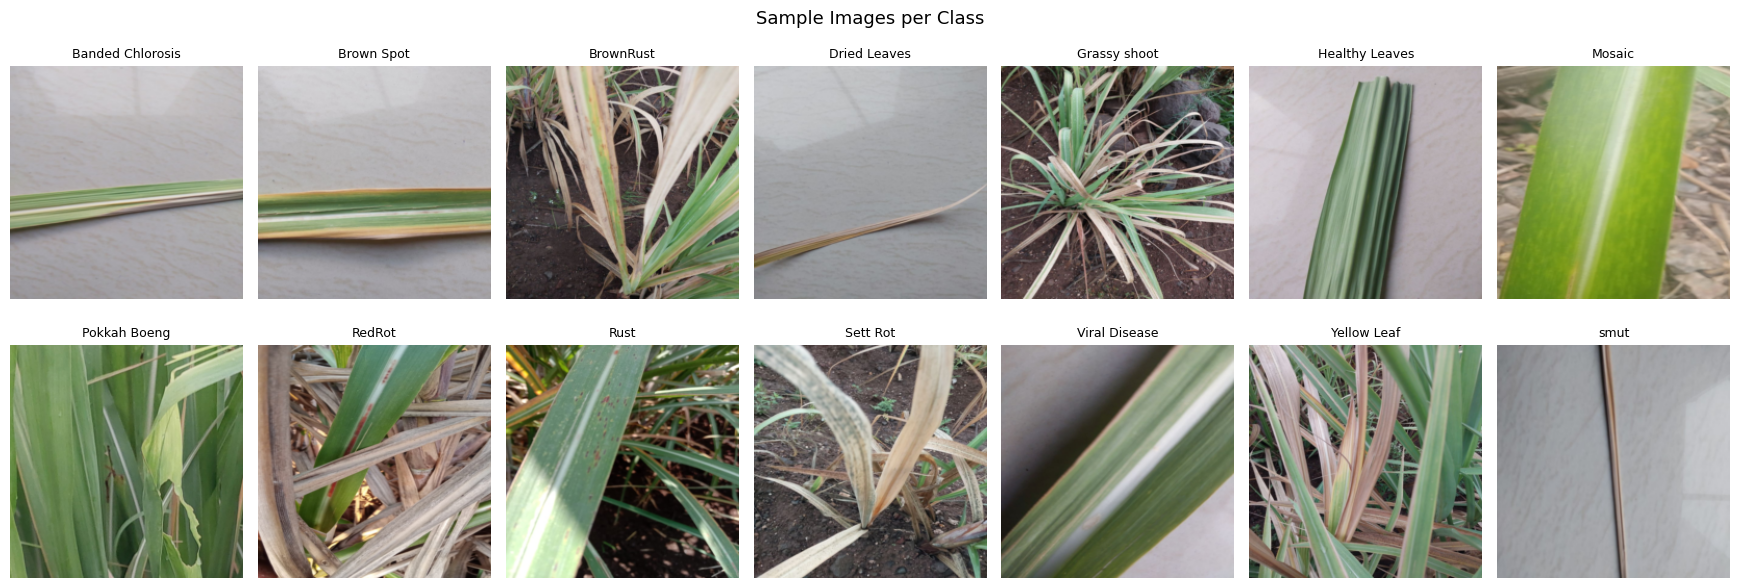

In [3]:
num_cols = 7
num_rows = (num_classes + num_cols - 1) // num_cols

fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2.5, num_rows * 3))
axs = axs.flatten()

collected = {}
for images, labels in train_loader:
    for img, label in zip(images, labels):
        label_idx = label.item()
        if label_idx not in collected:
            collected[label_idx] = img
        if len(collected) == num_classes:
            break
    if len(collected) == num_classes:
        break

for idx in range(num_classes):
    img = collected[idx]
    img_np = img.permute(1, 2, 0).numpy()
    img_np = (img_np * 0.5) + 0.5
    axs[idx].imshow(np.clip(img_np, 0, 1))
    axs[idx].set_title(class_names[idx], fontsize=9, wrap=True)
    axs[idx].axis('off')

for idx in range(num_classes, len(axs)):
    axs[idx].axis('off')

plt.tight_layout()
plt.suptitle("Sample Images per Class", fontsize=13, y=1.02)
plt.show()

## Class Weights — For Imbalanced Dataset Balancing
Compute class weights from training data and use in loss function during training.

In [4]:
from collections import Counter

# Count samples per class in training set
train_labels = [dataset.targets[i] for i in train_dataset.indices]
class_counts = Counter(train_labels)
total_samples = len(train_labels)

# Class weight formula: total / (num_classes * count_per_class)
class_weights = torch.tensor(
    [total_samples / (num_classes * class_counts[i]) for i in range(num_classes)],
    dtype=torch.float
).to('cuda')

print("Class Weights:")
for i, (name, w) in enumerate(zip(class_names, class_weights)):
    print(f"  {name}: {w.item():.4f}  (count: {class_counts[i]})")

Class Weights:
  Banded Chlorosis: 1.3711  (count: 338)
  Brown Spot: 0.3859  (count: 1201)
  BrownRust: 2.1161  (count: 219)
  Dried Leaves: 1.8839  (count: 246)
  Grassy shoot: 1.8174  (count: 255)
  Healthy Leaves: 0.6855  (count: 676)
  Mosaic: 1.4998  (count: 309)
  Pokkah Boeng: 2.3405  (count: 198)
  RedRot: 1.3394  (count: 346)
  Rust: 1.2458  (count: 372)
  Sett Rot: 1.0321  (count: 449)
  Viral Disease: 0.9818  (count: 472)
  Yellow Leaf: 0.3898  (count: 1189)
  smut: 2.1258  (count: 218)


## Transfer Learning Models
InceptionV3 uses an adaptive average pooling trick so it accepts 224×224 input instead of 299×299.

In [5]:
def get_transfer_model(model_name, num_classes):
    if model_name == "densenet201":
        model = models.densenet201(weights=models.DenseNet201_Weights.IMAGENET1K_V1)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == "inception_v3":
        model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        model.aux_logits = False
        model.AuxLogits = None
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "xception":
        # Xception is not in torchvision; we use timm
        import timm
        model = timm.create_model('xception', pretrained=True, num_classes=num_classes)
    else:
        raise ValueError(f"Model '{model_name}' not supported.")
    return model

## Early Stopping

In [6]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = np.inf

    def check_early_stop(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

## Training Function
Uses class_weights in CrossEntropyLoss for handling imbalanced dataset.

In [7]:
def train_model(model_name, num_classes, num_epochs=50, patience=5):
    model = get_transfer_model(model_name, num_classes).to('cuda')
    # Use class_weights for imbalanced dataset balancing (CW)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    early_stopping = EarlyStopping(patience=patience)
    scaler = amp.GradScaler('cuda')
    is_inception = (model_name == 'inception_v3')

    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        # ---- Training ----
        model.train()
        train_loss = 0
        for images, labels in tqdm(train_loader, desc="Training", leave=False):
            images, labels = images.to('cuda'), labels.to('cuda')
            optimizer.zero_grad()
            with amp.autocast('cuda'):
                if is_inception:
                     outputs = model(images)
                     loss = criterion(outputs, labels)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # ---- Validation ----
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation", leave=False):
                images, labels = images.to('cuda'), labels.to('cuda')
                with amp.autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                val_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss   / len(val_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        print(f"Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

        if early_stopping.check_early_stop(avg_val_loss):
            print("Early stopping triggered.")
            break

    pth_path = f'transfer_learning_{model_name}.pth'
    h5_path  = f'transfer_learning_{model_name}.h5'
    torch.save(model.state_dict(), pth_path)
    save_model_h5(model, h5_path)
    print(f"Model saved as '{pth_path}' and '{h5_path}'")

    return model, train_losses, val_losses

## Evaluation Function

In [8]:
def evaluate_model(model):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy  = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall    = recall_score(all_labels, all_preds, average='weighted')
    f1        = f1_score(all_labels, all_preds, average='weighted')

    print(f"Accuracy:  {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

## Loss Curve Function

In [9]:
def plot_loss_curve(train_losses, val_losses, model_name):
    plt.figure()
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses,   label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f"Training and Validation Loss for {model_name}")
    plt.show()

In [10]:
def save_model_h5(model, filepath):
    """Save PyTorch model weights to .h5 file"""
    with h5py.File(filepath, 'w') as f:
        for name, param in model.state_dict().items():
            f.create_dataset(name, data=param.cpu().numpy())
    print(f"Model saved as '{filepath}'")

---
## Model 1: DenseNet-201

In [11]:
densenet201_model, densenet201_train_losses, densenet201_val_losses = train_model(
    'densenet201', num_classes
)

Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:00<00:00, 179MB/s]


Epoch 1/50


Train Loss: 0.9730, Validation Loss: 0.7196
Epoch 2/50


Train Loss: 0.5257, Validation Loss: 0.5701
Epoch 3/50


...

Train Loss: 0.1622, Validation Loss: 0.2657
Epoch 17/50


Train Loss: 0.1923, Validation Loss: 0.1797
Epoch 18/50


Train Loss: 0.1191, Validation Loss: 0.1685
Epoch 19/50


Train Loss: 0.1417, Validation Loss: 0.2291
Epoch 20/50


Train Loss: 0.1111, Validation Loss: 0.2756
Early stopping triggered.
Model saved as 'transfer_learning_densenet201.h5'
Model saved as 'transfer_learning_densenet201.pth' and 'transfer_learning_densenet201.h5'


### Loss Curve for DenseNet-201

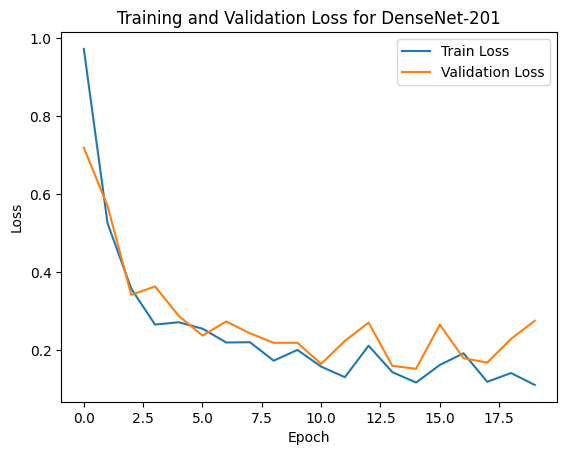

In [12]:
plot_loss_curve(densenet201_train_losses, densenet201_val_losses, 'DenseNet-201')

### Model Evaluation – DenseNet-201

In [13]:
evaluate_model(densenet201_model)

Accuracy:  90.19%
Precision: 0.9201
Recall:    0.9019
F1 Score:  0.9029


### XAI – Grad-CAM, Grad-CAM++, Eigen-CAM for DenseNet-201

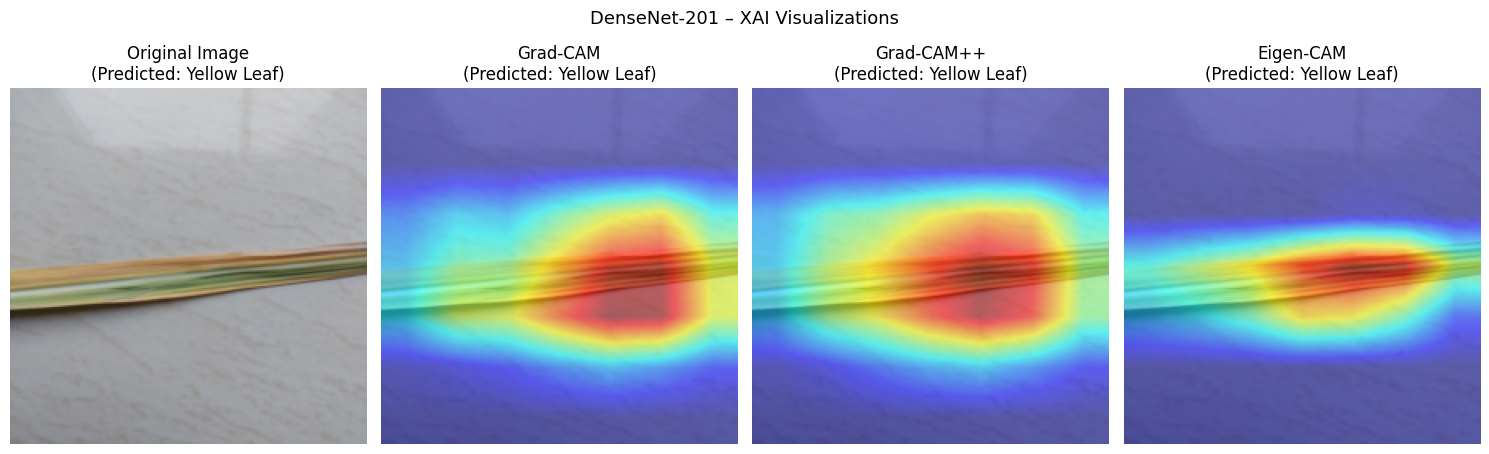

In [14]:
# ---- Load saved DenseNet-201 for XAI ----
xai_densenet201 = models.densenet201(weights=models.DenseNet201_Weights.IMAGENET1K_V1)
xai_densenet201.classifier = nn.Linear(xai_densenet201.classifier.in_features, num_classes)
xai_densenet201.load_state_dict(torch.load('transfer_learning_densenet201.pth'))
xai_densenet201 = xai_densenet201.to('cuda')
xai_densenet201.eval()

# Find a correctly predicted sample
sample_image, sample_label = None, None
for img, lbl in test_dataset:
    img_tensor = img.unsqueeze(0).to('cuda')
    with torch.no_grad():
        out = xai_densenet201(img_tensor)
        pred = out.argmax().item()
    if pred == lbl:
        sample_image = img_tensor
        sample_label = lbl
        break

if sample_image is None:
    img, lbl = test_dataset[0]
    sample_image = img.unsqueeze(0).to('cuda')
    sample_label = lbl

original_image_np = sample_image.squeeze(0).permute(1, 2, 0).cpu().numpy()
original_image_np = (original_image_np * 0.5) + 0.5
original_image_np = np.clip(original_image_np, 0, 1).astype(np.float32)

with torch.no_grad():
    outputs = xai_densenet201(sample_image)
    predicted_class = outputs.argmax().item()
    predicted_class_name = class_names[predicted_class]

# DenseNet target layer: last denseblock
target_layers = [xai_densenet201.features.denseblock4]
target = [ClassifierOutputTarget(predicted_class)]

gradcam        = GradCAM(model=xai_densenet201,        target_layers=target_layers)
gradcam_pp     = GradCAMPlusPlus(model=xai_densenet201, target_layers=target_layers)
eigen_cam      = EigenCAM(model=xai_densenet201,        target_layers=target_layers)

gradcam_heatmap    = gradcam(input_tensor=sample_image,    targets=target)[0]
gradcam_pp_heatmap = gradcam_pp(input_tensor=sample_image, targets=target)[0]
eigen_cam_heatmap  = eigen_cam(input_tensor=sample_image,  targets=target)[0]

gradcam_result    = show_cam_on_image(original_image_np, gradcam_heatmap,    use_rgb=True)
gradcam_pp_result = show_cam_on_image(original_image_np, gradcam_pp_heatmap, use_rgb=True)
eigen_cam_result  = show_cam_on_image(original_image_np, eigen_cam_heatmap,  use_rgb=True)

plt.figure(figsize=(15, 5))
for i, (img_data, title) in enumerate([
    (original_image_np, f"Original Image\n(Predicted: {predicted_class_name})"),
    (gradcam_result,    f"Grad-CAM\n(Predicted: {predicted_class_name})"),
    (gradcam_pp_result, f"Grad-CAM++\n(Predicted: {predicted_class_name})"),
    (eigen_cam_result,  f"Eigen-CAM\n(Predicted: {predicted_class_name})")
]):
    plt.subplot(1, 4, i+1)
    plt.imshow(img_data)
    plt.title(title)
    plt.axis('off')
plt.suptitle("DenseNet-201 – XAI Visualizations", fontsize=13)
plt.tight_layout()
plt.show()

---
## Model 2: InceptionV3

In [15]:
inception_model, inception_train_losses, inception_val_losses = train_model(
    'inception_v3', num_classes
)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 171MB/s] 


Epoch 1/50


Train Loss: 1.3090, Validation Loss: 1.2457
Epoch 2/50


Train Loss: 0.7386, Validation Loss: 0.8578
Epoch 3/50


...

Train Loss: 0.1232, Validation Loss: 0.1861
Epoch 24/50


Train Loss: 0.1752, Validation Loss: 0.1690
Epoch 25/50


Train Loss: 0.1625, Validation Loss: 0.3852
Epoch 26/50


Train Loss: 0.1531, Validation Loss: 0.2094
Epoch 27/50


Train Loss: 0.1488, Validation Loss: 0.2983
Early stopping triggered.
Model saved as 'transfer_learning_inception_v3.h5'
Model saved as 'transfer_learning_inception_v3.pth' and 'transfer_learning_inception_v3.h5'


### Loss Curve for InceptionV3

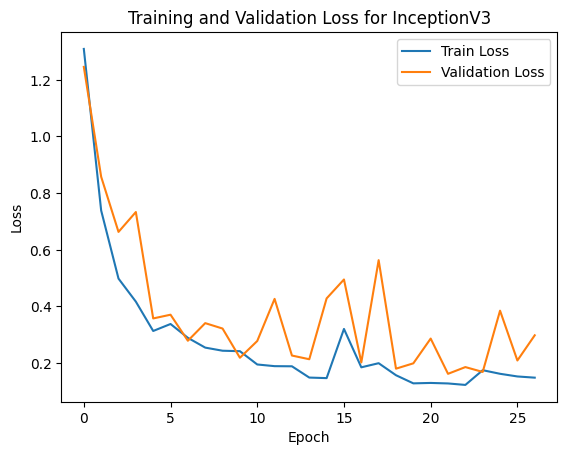

In [16]:
plot_loss_curve(inception_train_losses, inception_val_losses, 'InceptionV3')

### Model Evaluation – InceptionV3

In [17]:
evaluate_model(inception_model)

Accuracy:  90.62%
Precision: 0.9198
Recall:    0.9062
F1 Score:  0.9095


### XAI – Grad-CAM, Grad-CAM++, Eigen-CAM for InceptionV3

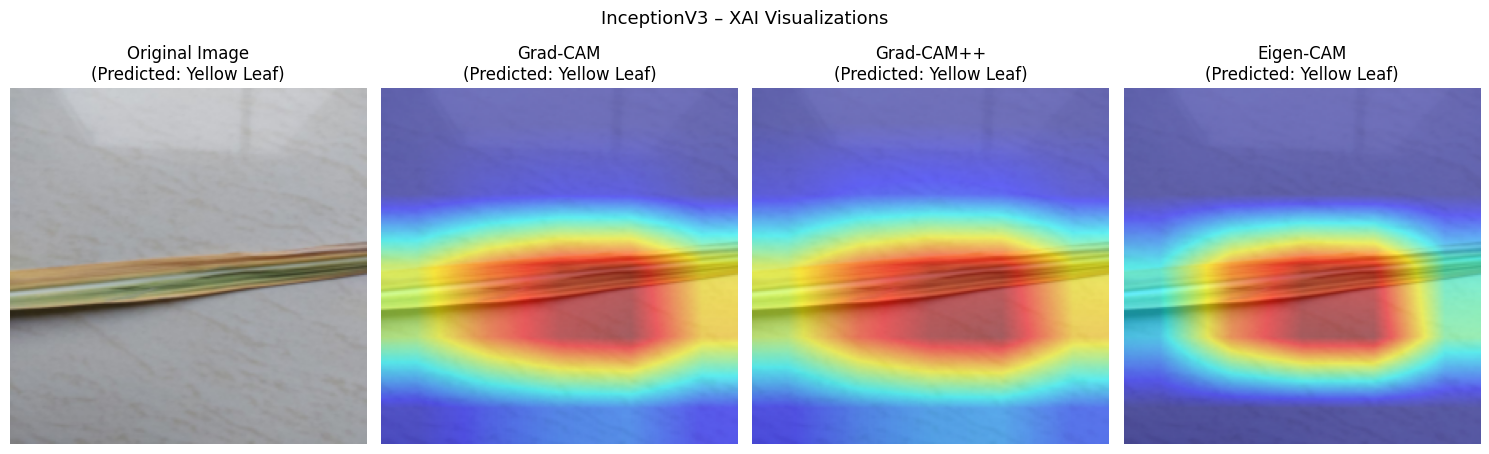

In [18]:
xai_inception = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
xai_inception.fc = nn.Linear(xai_inception.fc.in_features, num_classes)
xai_inception.AuxLogits = None
xai_inception.load_state_dict(torch.load('transfer_learning_inception_v3.pth'))
xai_inception = xai_inception.to('cuda')
xai_inception.eval()

# Find a correctly predicted sample from InceptionV3 test set
sample_image, sample_label = None, None
for img, lbl in test_dataset:
    img_tensor = img.unsqueeze(0).to('cuda')
    with torch.no_grad():
        out = xai_inception(img_tensor)
        pred = out.argmax().item()
    if pred == lbl:
        sample_image = img_tensor
        sample_label = lbl
        break

if sample_image is None:
    img, lbl = test_dataset[0]
    sample_image = img.unsqueeze(0).to('cuda')
    sample_label = lbl

original_image_np = sample_image.squeeze(0).permute(1, 2, 0).cpu().numpy()
original_image_np = (original_image_np * 0.5) + 0.5
original_image_np = np.clip(original_image_np, 0, 1).astype(np.float32)

with torch.no_grad():
    outputs = xai_inception(sample_image)
    predicted_class = outputs.argmax().item()
    predicted_class_name = class_names[predicted_class]

# InceptionV3 target layer: last Mixed block
target_layers = [xai_inception.Mixed_7c]
target = [ClassifierOutputTarget(predicted_class)]

gradcam        = GradCAM(model=xai_inception,        target_layers=target_layers)
gradcam_pp     = GradCAMPlusPlus(model=xai_inception, target_layers=target_layers)
eigen_cam      = EigenCAM(model=xai_inception,        target_layers=target_layers)

gradcam_heatmap    = gradcam(input_tensor=sample_image,    targets=target)[0]
gradcam_pp_heatmap = gradcam_pp(input_tensor=sample_image, targets=target)[0]
eigen_cam_heatmap  = eigen_cam(input_tensor=sample_image,  targets=target)[0]

gradcam_result    = show_cam_on_image(original_image_np, gradcam_heatmap,    use_rgb=True)
gradcam_pp_result = show_cam_on_image(original_image_np, gradcam_pp_heatmap, use_rgb=True)
eigen_cam_result  = show_cam_on_image(original_image_np, eigen_cam_heatmap,  use_rgb=True)

plt.figure(figsize=(15, 5))
for i, (img_data, title) in enumerate([
    (original_image_np, f"Original Image\n(Predicted: {predicted_class_name})"),
    (gradcam_result,    f"Grad-CAM\n(Predicted: {predicted_class_name})"),
    (gradcam_pp_result, f"Grad-CAM++\n(Predicted: {predicted_class_name})"),
    (eigen_cam_result,  f"Eigen-CAM\n(Predicted: {predicted_class_name})")
]):
    plt.subplot(1, 4, i+1)
    plt.imshow(img_data)
    plt.title(title)
    plt.axis('off')
plt.suptitle("InceptionV3 – XAI Visualizations", fontsize=13)
plt.tight_layout()
plt.show()

---
## Model 3: Xception

In [19]:
xception_model, xception_train_losses, xception_val_losses = train_model(
    'xception', num_classes
)

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
Epoch 1/50


Train Loss: 0.8023, Validation Loss: 0.4491
Epoch 2/50


Train Loss: 0.3380, Validation Loss: 0.3196
Epoch 3/50


Train Loss: 0.2768, Validation Loss: 0.2948
Epoch 4/50


...

Train Loss: 0.1335, Validation Loss: 0.1959
Epoch 10/50


Train Loss: 0.1272, Validation Loss: 0.2099
Epoch 11/50


Train Loss: 0.1872, Validation Loss: 0.2401
Epoch 12/50


Train Loss: 0.1286, Validation Loss: 0.1898
Epoch 13/50


Train Loss: 0.1195, Validation Loss: 0.1727
Early stopping triggered.
Model saved as 'transfer_learning_xception.h5'
Model saved as 'transfer_learning_xception.pth' and 'transfer_learning_xception.h5'


### Loss Curve for Xception

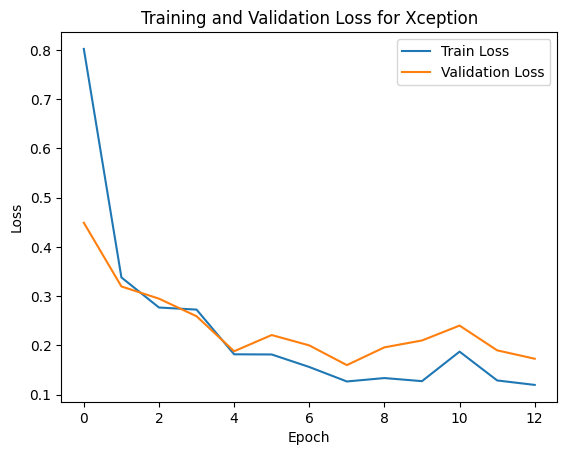

In [20]:
plot_loss_curve(xception_train_losses, xception_val_losses, 'Xception')

### Model Evaluation – Xception

In [21]:
evaluate_model(xception_model)

Accuracy:  94.72%
Precision: 0.9489
Recall:    0.9472
F1 Score:  0.9464


### XAI – Grad-CAM, Grad-CAM++, Eigen-CAM for Xception

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


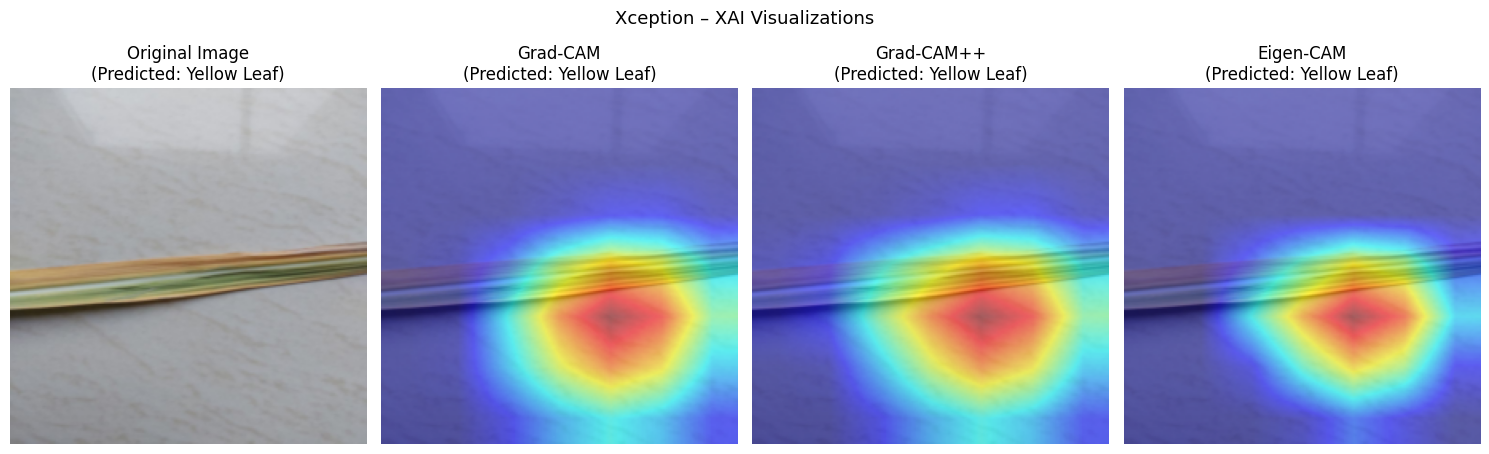

In [22]:
import timm

xai_xception = timm.create_model('xception', pretrained=False, num_classes=num_classes)
xai_xception.load_state_dict(torch.load('transfer_learning_xception.pth'))
xai_xception = xai_xception.to('cuda')
xai_xception.eval()

# Find a correctly predicted sample
sample_image, sample_label = None, None
for img, lbl in test_dataset:
    img_tensor = img.unsqueeze(0).to('cuda')
    with torch.no_grad():
        out = xai_xception(img_tensor)
        pred = out.argmax().item()
    if pred == lbl:
        sample_image = img_tensor
        sample_label = lbl
        break

if sample_image is None:
    img, lbl = test_dataset[0]
    sample_image = img.unsqueeze(0).to('cuda')
    sample_label = lbl

original_image_np = sample_image.squeeze(0).permute(1, 2, 0).cpu().numpy()
original_image_np = (original_image_np * 0.5) + 0.5
original_image_np = np.clip(original_image_np, 0, 1).astype(np.float32)

with torch.no_grad():
    outputs = xai_xception(sample_image)
    predicted_class = outputs.argmax().item()
    predicted_class_name = class_names[predicted_class]

# Xception target layer: last block before global avg pooling
target_layers = [xai_xception.act4]  # final activation before head
target = [ClassifierOutputTarget(predicted_class)]

gradcam        = GradCAM(model=xai_xception,        target_layers=target_layers)
gradcam_pp     = GradCAMPlusPlus(model=xai_xception, target_layers=target_layers)
eigen_cam      = EigenCAM(model=xai_xception,        target_layers=target_layers)

gradcam_heatmap    = gradcam(input_tensor=sample_image,    targets=target)[0]
gradcam_pp_heatmap = gradcam_pp(input_tensor=sample_image, targets=target)[0]
eigen_cam_heatmap  = eigen_cam(input_tensor=sample_image,  targets=target)[0]

gradcam_result    = show_cam_on_image(original_image_np, gradcam_heatmap,    use_rgb=True)
gradcam_pp_result = show_cam_on_image(original_image_np, gradcam_pp_heatmap, use_rgb=True)
eigen_cam_result  = show_cam_on_image(original_image_np, eigen_cam_heatmap,  use_rgb=True)

plt.figure(figsize=(15, 5))
for i, (img_data, title) in enumerate([
    (original_image_np, f"Original Image\n(Predicted: {predicted_class_name})"),
    (gradcam_result,    f"Grad-CAM\n(Predicted: {predicted_class_name})"),
    (gradcam_pp_result, f"Grad-CAM++\n(Predicted: {predicted_class_name})"),
    (eigen_cam_result,  f"Eigen-CAM\n(Predicted: {predicted_class_name})")
]):
    plt.subplot(1, 4, i+1)
    plt.imshow(img_data)
    plt.title(title)
    plt.axis('off')
plt.suptitle("Xception – XAI Visualizations", fontsize=13)
plt.tight_layout()
plt.show()